Benchmark
============

Adding all planners
===========


In [1]:
import matplotlib.pylab as plt
%matplotlib inline
from IPPerfMonitor import IPPerfMonitor
#import IPBasicPRM
#import IPVISBasicPRM

#import IPVisibilityPRM
#import IPVISVisibilityPRM

#import IPLazyPRM
#import IPVISLazyPRM

#import IPRRT
#import IPVISRRT

import IPAStar
import IPVISAStar

Set-up of the test scenario and the configuration for all planner
===================================

Following a procedure to compare all discussed planners are shown:

1. Configuration for every planner is defined
2. The configuration and the planner is stored in the variable setup, a Python dict()
3. the variable setup is then used to uniformly call the planning calls


In [2]:
plannerFactory = dict()

#basicConfig = dict()
#basicConfig["radius"] = 3
#basicConfig["numNodes"] = 200
#plannerFactory["basePRM"] = [IPBasicPRM.BasicPRM, basicConfig, IPVISBasicPRM.basicPRMVisualize]

#visbilityConfig = dict()
#visbilityConfig["ntry"] = 300
#plannerFactory["visibilityPRM"] = [IPVisibilityPRM.VisPRM, visbilityConfig, IPVISVisibilityPRM.visibilityPRMVisualize ]

#lazyConfig = dict()
#lazyConfig["initialRoadmapSize"] = 10
#lazyConfig["updateRoadmapSize"]  = 5 
#lazyConfig["kNearest"] = 8
#lazyConfig["maxIterations"] = 20
#plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, IPVISLazyPRM.lazyPRMVisualize]

astarConfig = dict()
astarConfig["heuristic"] = 'euclidean' 
astarConfig["w"]  = 0.7
plannerFactory["astar"] = [IPAStar.AStar, astarConfig, IPVISAStar.aStarVisualizeWspace]

#astarConfig2 = dict()
#astarConfig2["heuristic"] = 'euclidean' 
#astarConfig2["w"]  = 0.9
#plannerFactory["astar2"] = [IPAStar.AStar, astarConfig2, IPVISAStar.aStarVisualize]





In [3]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [4]:
import IPTestSuite3 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting
from IPEnvironmentKin import animateSolution


In [5]:
#import importlib
#importlib.reload(IPTestSuiteSS2024)

In [6]:
fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)

obst


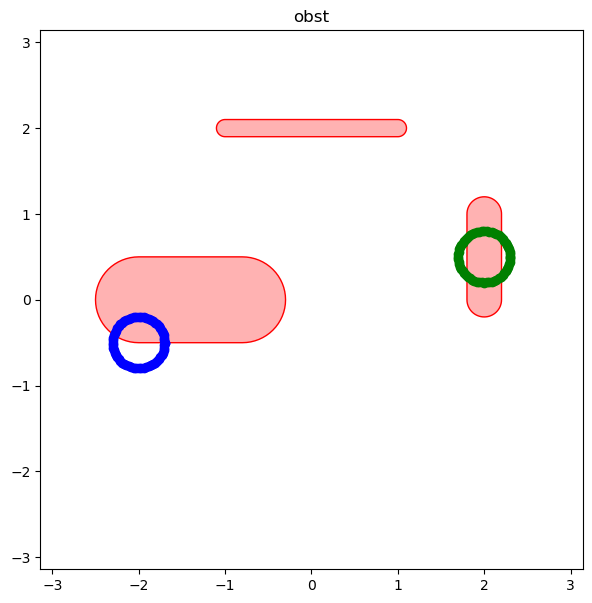

In [7]:
for benchmark in fullBenchList:
    fig_local = plt.figure(figsize=(7,7))
    ax = fig_local.add_subplot(1,1,1)
    title = benchmark.name
    ax.set_title(title)
    ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
    plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
    plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
    #try:
    benchmark.collisionChecker.drawObstacles(ax,True)
   

        
    #except Exception as e:
    #    print ("Error", e)
    #    pass
    plt.show()

In [8]:
resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass



astar [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.7}, <function aStarVisualizeWspace at 0x00000264C3669440>]
Planning: astar - obst


In [9]:
for bench in testList:
    for result in resultList:
        if result.benchmark.name == bench.name:
            if result.solution is not None :
                print(result.plannerFactoryName)
                animateSolution(result.planner, bench.collisionChecker, result.solution, plannerFactory[result.plannerFactoryName][2])
                #animate_solution_multi_downsampled(
                #    result.planner, bench.collisionChecker, result.solution,
                #    visualizer=plannerFactory[result.plannerFactoryName][2],
                #    step_l=0.4, interval=60, max_frames=80, figsize=(20,20), dpi=50)

astar


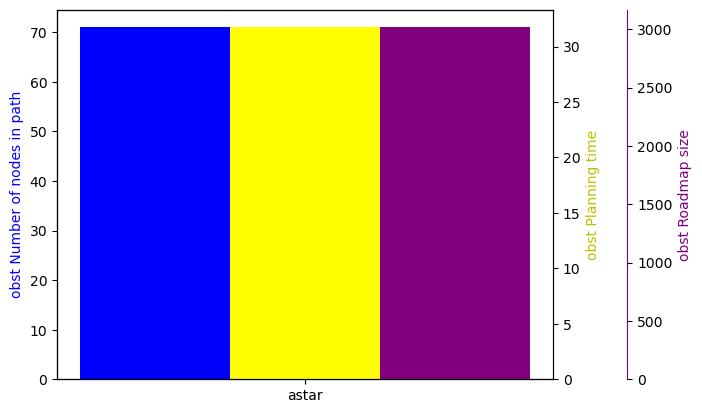

In [10]:
import numpy as np
for bench in testList:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    
    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()


        fig, ax = plt.subplots()

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " Number of nodes in path", color="blue")
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys())

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " Planning time", color="y")

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")
    except:
        pass

    plt.show()


    
        
    